<h1>PROJECT LOGIKA FUZZY

<p>Fuzzy Database Model Tahani vs Umano
<p>Kasus   : Seleksi Penerima Beasiswa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

<h3>Load Dataset

In [2]:
df = pd.read_excel(
    "Data_Penerima_Beasiswa.xlsx"
)

df.head()

,No,Nama,IPK,Penghasilan (Juta),Prestasi (0-100),Tanggungan,Nilai Fuzzy,Kategori
0,1,Andi,3.8,2.5,85,4,82.5,LAYAK
1,2,Budi,2.8,8.0,60,1,30.2,TIDAK LAYAK
2,3,Citra,3.9,1.5,90,5,85.0,LAYAK
3,4,Dedi,2.5,12.0,50,3,20.0,TIDAK LAYAK
4,5,Eka,3.5,3.0,80,3,78.4,LAYAK


In [3]:
print(df.shape)
print(df.info())

(20, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   No                  20 non-null     int64  
 1   Nama                20 non-null     object 
 2   IPK                 20 non-null     float64
 3   Penghasilan (Juta)  20 non-null     float64
 4   Prestasi (0-100)    20 non-null     int64  
 5   Tanggungan          20 non-null     int64  
 6   Nilai Fuzzy         20 non-null     float64
 7   Kategori            20 non-null     object 
dtypes: float64(3), int64(3), object(2)
memory usage: 1.4+ KB
None


<h3>Analisis Dataset

In [4]:
df.describe()

,No,IPK,Penghasilan (Juta),Prestasi (0-100),Tanggungan,Nilai Fuzzy
count,20.00000,20.0000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,3.2350,5.705000,72.250000,3.250000,56.115000
std,5.91608,0.4995,3.892567,15.296628,1.251315,26.049271
min,1.00000,2.4000,1.000000,45.000000,1.000000,15.500000
25%,5.75000,2.8375,2.725000,61.500000,2.000000,29.775000
50%,10.50000,3.2500,4.750000,73.500000,3.000000,55.000000
75%,15.25000,3.6750,8.125000,85.000000,4.000000,80.700000
max,20.00000,3.9500,15.000000,95.000000,6.000000,88.200000


<h3>Membership Function

In [7]:
def ipk_rendah(x):

    if x <= 2.75:
        return 1

    elif x < 3.25:
        return (3.25 - x) / (3.25 - 2.75)

    else:
        return 0

In [8]:
def ipk_sedang(x):

    if x <= 2.5:
        return 0

    elif x < 3.25:
        return (x - 2.5) / (3.25 - 2.5)

    elif x < 4.0:
        return (4.0 - x) / (4.0 - 3.25)

    else:
        return 0

In [9]:
def ipk_tinggi(x):

    if x <= 3.5:
        return 0

    elif x < 4.0:
        return (x - 3.5) / (4.0 - 3.5)

    else:
        return 1

In [11]:
def penghasilan_rendah(x):

    if x <= 3:
        return 1

    elif x < 5:
        return (5 - x)/(5 - 3)

    else:
        return 0

In [12]:
def penghasilan_sedang(x):

    if x <= 3:
        return 0

    elif x < 6:
        return (x - 3)/(6 - 3)

    elif x < 9:
        return (9 - x)/(9 - 6)

    else:
        return 0

In [13]:
def penghasilan_tinggi(x):

    if x <= 7:
        return 0

    elif x < 10:
        return (x - 7)/(10 - 7)

    else:
        return 1

In [14]:
def prestasi_rendah(x):

    if x <= 60:
        return 1

    elif x < 75:
        return (75 - x)/(75 - 60)

    else:
        return 0

In [15]:
def prestasi_sedang(x):

    if x <= 60:
        return 0

    elif x < 75:
        return (x - 60)/(75 - 60)

    elif x < 90:
        return (90 - x)/(90 - 75)

    else:
        return 0

In [16]:
def prestasi_tinggi(x):

    if x <= 80:
        return 0

    elif x < 95:
        return (x - 80)/(95 - 80)

    else:
        return 1

In [17]:
def tanggungan_sedikit(x):

    if x <= 2:
        return 1

    elif x < 3:
        return (3 - x)/(3 - 2)

    else:
        return 0

In [18]:
def tanggungan_sedang(x):

    if x <= 2:
        return 0

    elif x < 4:
        return (x - 2)/(4 - 2)

    elif x < 6:
        return (6 - x)/(6 - 4)

    else:
        return 0

In [19]:
def tanggungan_banyak(x):

    if x <= 4:
        return 0

    elif x < 6:
        return (x - 4)/(6 - 4)

    else:
        return 1

<h3>Garfik Membership Function

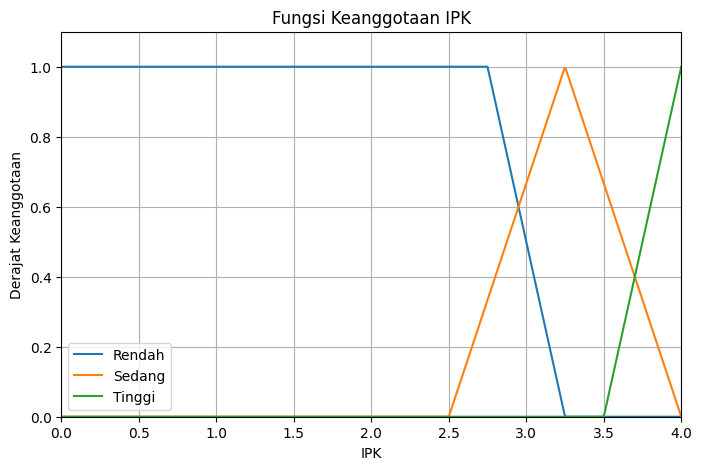

In [27]:
x_ipk = np.linspace(0,4,500)

ipk_r = [ipk_rendah(i) for i in x_ipk]
ipk_s = [ipk_sedang(i) for i in x_ipk]
ipk_t = [ipk_tinggi(i) for i in x_ipk]

plt.figure(figsize=(8,5))

plt.plot(x_ipk, ipk_r, label="Rendah")
plt.plot(x_ipk, ipk_s, label="Sedang")
plt.plot(x_ipk, ipk_t, label="Tinggi")

plt.title("Fungsi Keanggotaan IPK")

plt.xlabel("IPK")
plt.ylabel("Derajat Keanggotaan")

plt.xlim(0,4)
plt.ylim(0,1.1)

plt.grid(True)
plt.legend()

plt.show()

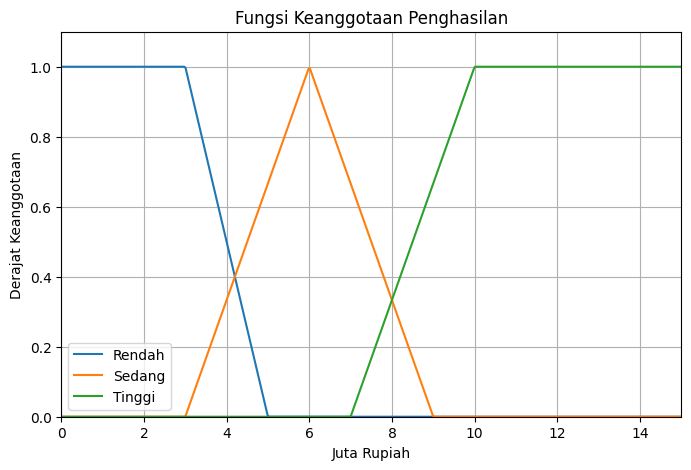

In [29]:
x_penghasilan = np.linspace(0,15,500)

peng_r = [penghasilan_rendah(i) for i in x_penghasilan]
peng_s = [penghasilan_sedang(i) for i in x_penghasilan]
peng_t = [penghasilan_tinggi(i) for i in x_penghasilan]

plt.figure(figsize=(8,5))

plt.plot(x_penghasilan, peng_r, label="Rendah")
plt.plot(x_penghasilan, peng_s, label="Sedang")
plt.plot(x_penghasilan, peng_t, label="Tinggi")

plt.title("Fungsi Keanggotaan Penghasilan")

plt.xlabel("Juta Rupiah")
plt.ylabel("Derajat Keanggotaan")

plt.xlim(0,15)
plt.ylim(0,1.1)

plt.grid(True)
plt.legend()

plt.show()

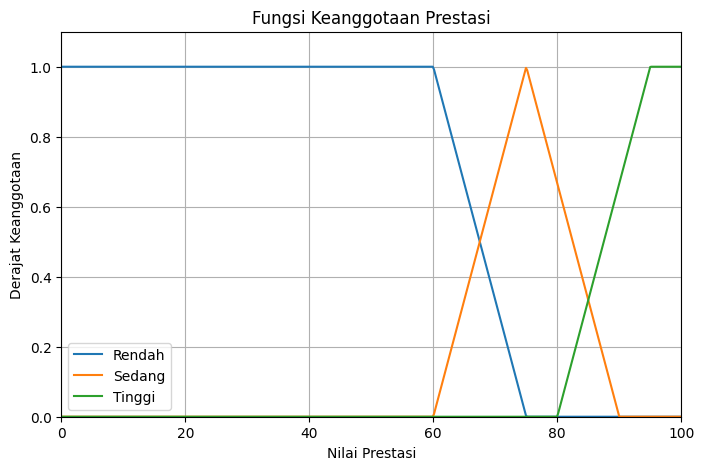

In [30]:
x_prestasi = np.linspace(0,100,500)
pres_r = [prestasi_rendah(i) for i in x_prestasi]
pres_s = [prestasi_sedang(i) for i in x_prestasi]
pres_t = [prestasi_tinggi(i) for i in x_prestasi]

plt.figure(figsize=(8,5))

plt.plot(x_prestasi, pres_r, label="Rendah")
plt.plot(x_prestasi, pres_s, label="Sedang")
plt.plot(x_prestasi, pres_t, label="Tinggi")

plt.title("Fungsi Keanggotaan Prestasi")

plt.xlabel("Nilai Prestasi")
plt.ylabel("Derajat Keanggotaan")

plt.xlim(0,100)
plt.ylim(0,1.1)

plt.grid(True)
plt.legend()

plt.show()

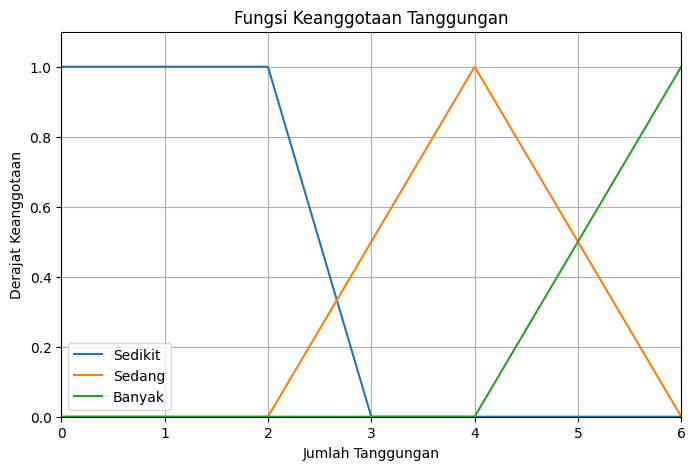

In [31]:
x_tanggungan = np.linspace(0,6,500)

tang_sedikit = [tanggungan_sedikit(i) for i in x_tanggungan]
tang_sedang = [tanggungan_sedang(i) for i in x_tanggungan]
tang_banyak = [tanggungan_banyak(i) for i in x_tanggungan]

plt.figure(figsize=(8,5))

plt.plot(x_tanggungan, tang_sedikit, label="Sedikit")
plt.plot(x_tanggungan, tang_sedang, label="Sedang")
plt.plot(x_tanggungan, tang_banyak, label="Banyak")

plt.title("Fungsi Keanggotaan Tanggungan")

plt.xlabel("Jumlah Tanggungan")
plt.ylabel("Derajat Keanggotaan")

plt.xlim(0,6)
plt.ylim(0,1.1)

plt.grid(True)
plt.legend()

plt.show()

<h3>Fuzzification

In [32]:
print("\nFuzzification...")

df["ipk_tinggi"] = df["IPK"].apply(
    ipk_tinggi
)

df["income_rendah"] = df[
    "Penghasilan (Juta)"
].apply(
    income_rendah
)

df["prestasi_tinggi"] = df[
    "Prestasi (0-100)"
].apply(
    prestasi_tinggi
)

df["tanggungan_banyak"] = df[
    "Tanggungan"
].apply(
    tanggungan_banyak
)


print(

df[
[
"ipk_tinggi",

"income_rendah",

"prestasi_tinggi",

"tanggungan_banyak"

]

].head()

)


Fuzzification...
   ipk_tinggi  income_rendah  prestasi_tinggi  tanggungan_banyak
0         0.6           0.75         0.333333                0.0
1         0.0           0.00         0.000000                0.0
2         0.8           1.00         0.666667                0.5
3         0.0           0.00         0.000000                0.0
4         0.0           0.50         0.000000                0.0


<h3>Implementasi Model Tahani

In [33]:
print("\nTahani Ranking...")


"""
QUERY FUZZY:

IPK tinggi

AND

Income rendah

AND

Prestasi tinggi

AND

Tanggungan banyak

Operator:

MIN
"""


query_columns = [

"ipk_tinggi",

"income_rendah",

"prestasi_tinggi",

"tanggungan_banyak"

]


df["score_tahani"] = (

df[query_columns]

.min(axis=1)

)



ranking_tahani = (

df

.sort_values(

"score_tahani",

ascending=False

)

)


print(

ranking_tahani[

["Nama",

"score_tahani"]

]

.head(20)

)


Tahani Ranking...
      Nama  score_tahani
10  Kurnia           0.9
2    Citra           0.5
15   Putri           0.5
0     Andi           0.0
3     Dedi           0.0
1     Budi           0.0
6     Gita           0.0
4      Eka           0.0
7     Hani           0.0
8    Indra           0.0
9     Joko           0.0
5    Fajar           0.0
11    Lani           0.0
12    Miko           0.0
13    Nana           0.0
14     Oki           0.0
16    Qori           0.0
17    Rian           0.0
18   Siska           0.0
19    Tono           0.0


<h3>Implementasi Model Umano

In [34]:
print("\nUmano Ranking...")


"""
Product Aggregation

score =

membership1

×

membership2

×

membership3

×

membership4
"""


df["score_umano"] = (

df["ipk_tinggi"]

*

df["income_rendah"]

*

df["prestasi_tinggi"]

*

df["tanggungan_banyak"]

)



ranking_umano=(

df

.sort_values(

"score_umano",

ascending=False

)

)


print(

ranking_umano[

["Nama",

"score_umano"]

]

.head(20)

)


Umano Ranking...
      Nama  score_umano
10  Kurnia     0.900000
15   Putri     0.280000
2    Citra     0.266667
0     Andi     0.000000
3     Dedi     0.000000
1     Budi     0.000000
6     Gita     0.000000
4      Eka     0.000000
7     Hani     0.000000
8    Indra     0.000000
9     Joko     0.000000
5    Fajar     0.000000
11    Lani     0.000000
12    Miko     0.000000
13    Nana     0.000000
14     Oki     0.000000
16    Qori     0.000000
17    Rian     0.000000
18   Siska     0.000000
19    Tono     0.000000


<h3>Perbandingan Model

In [35]:
comparison = df[

[

"Nama",

"score_tahani",

"score_umano"

]

]


comparison = comparison.sort_values(

"score_umano",

ascending=False

)


print("\nComparison")


print(

comparison.head(20)

)


Comparison
      Nama  score_tahani  score_umano
10  Kurnia           0.9     0.900000
15   Putri           0.5     0.280000
2    Citra           0.5     0.266667
0     Andi           0.0     0.000000
3     Dedi           0.0     0.000000
1     Budi           0.0     0.000000
6     Gita           0.0     0.000000
4      Eka           0.0     0.000000
7     Hani           0.0     0.000000
8    Indra           0.0     0.000000
9     Joko           0.0     0.000000
5    Fajar           0.0     0.000000
11    Lani           0.0     0.000000
12    Miko           0.0     0.000000
13    Nana           0.0     0.000000
14     Oki           0.0     0.000000
16    Qori           0.0     0.000000
17    Rian           0.0     0.000000
18   Siska           0.0     0.000000
19    Tono           0.0     0.000000


<h3>Export Hasil

In [36]:
comparison.to_excel(

"hasil_ranking_fuzzy.xlsx",

index=False

)


print(

"\nFile berhasil dibuat"

)

print(

"hasil_ranking_fuzzy.xlsx"

)


File berhasil dibuat
hasil_ranking_fuzzy.xlsx
